In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy

from scipy.stats import norm

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [30]:
# data analysis global functions
def load_dataset(month, year):
    #Takes in desired month and year and outputs
    # x: hourly x data
    # y: corresponding TLV value
    # month_data: Dataframe in pivot table format with hour of day for rows and day of month for columns
    # month_temporal_melted: melted version of month_data DataFrame
    
    month_data = pd.read_csv(str(year) + " Pivot Data Tables/" + month + " TLV Pivot.csv")
    month_data = month_data.set_index('Hour of the Day')
    month_data.columns = month_data.columns.astype(int)
    month_data.index = month_data.index.astype(int)
    month_data = month_data.astype(float)

    month_temporal_melted = pd.melt(month_data.reset_index(), id_vars=['Hour of the Day'], var_name='1', value_name='Value')
    x = month_temporal_melted["Hour of the Day"]
    y = month_temporal_melted["Value"]
    
    return x, y, month_data, month_temporal_melted


def lin_reg(x, y, month, year):
    # Takes in month_data and name of month and prints out linear regression intercept, slope, and the graph. 
    # It also updates the regression error table and outputs the melted temporal dataframe for further analysis
    
    # Augmenting x matrix
    x_matrix = []
    for i in x:
        x_matrix.append([1, i])
    
    x_matrix = np.array(x_matrix)
    
    # Finding optimal linear weights
    w = np.linalg.solve(x_matrix.T @ x_matrix, x_matrix.T @ y)
    
    #w[0]: intercept, w[1]: slope
    print("intercept = w[0]:", w[0])
    print("slope = w[1]:", w[1])

    #Update MSE Risk Table
    y_true = y
    y_pred = x_matrix @ w
    mse = mean_squared_error(y_true, y_pred)
    reg_errors[year].loc[month,'Linear'] = mse
    print("MSE using linear regression:", mse) #Bad MSE, very large

    # Setting Plot Type
    plt.scatter(x, y, label='Data points')
    
    # Labels and title
    plt.xlabel('Hour of the Day')
    plt.ylabel('TLV')
    plt.title('TLV by Hour using Empirical Risk Minimization w.r.t. MSE')
    
    # Plot regression line
    reg_line = w[1] * x + w[0]
    plt.plot(x, reg_line, color='red', label=f'MSE Reg Line')
    
    # Show the plot
    plt.legend()
    plt.show()
    
    return x_matrix

def knn_predict(X_train, y_train, x, k=1):
    predictions = []
    
    for x in X_test:
        # Calculate distances between the test point and all training points
        distances = np.linalg.norm(X_train - x, axis=1)
        # Find the indices of the k nearest neighbors
        nearest_neighbors = np.argpartition(distances, k, axis=0)[:k]
        # Average the target values of the k nearest neighbors
        prediction = np.mean(y_train[nearest_neighbors])
        predictions.append(prediction)
    
    return np.array(predictions)

# automatically clustering values

def create_clusters(melted_temporal_df, k=3):
    # Takes in a melted temporal df and desired number of clusters
    # Outputs a copy of the melted temporal df with the addition of a new cluster column and the scaled and unscaled centroids
    
    df = melted_temporal_df.copy()
    scaler = StandardScaler()
    melted_temporal_df_scaled = scaler.fit_transform(df[["Hour of the Day", "Value"]])

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    df['Cluster'] = kmeans.fit_predict(melted_temporal_df_scaled)  
    scaled_centroids = kmeans.cluster_centers_
    unscaled_centroids = scaler.inverse_transform(kmeans.cluster_centers_)

    return df, melted_temporal_df_scaled, scaled_centroids, unscaled_centroids

def create_cluster_scatterplots(melted_temporal_df, create_clusters):
    # Takes in a melted temporal dataframe and the create_clusters function
    # Outputs two scatterplots, one scaled and one unscaled, with data grouped into clusters and centroids identified

    clusters = create_clusters(melted_temporal_df)
    
    x_scaled = clusters[1].T[0]
    y_scaled = clusters[1].T[1]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=x_scaled, y=y_scaled, hue=clusters[0]['Cluster'])
    plt.scatter(clusters[2][:, 0], clusters[2][:, 1], color='red', marker='X', s=200, label='Centroids')
    plt.title('K-Means Clustering Scaled')
    plt.legend()
    plt.show()


    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=melted_temporal_df['Hour of the Day'], y=melted_temporal_df['Value'], hue=clusters[0]['Cluster'])
    plt.scatter(clusters[3][:, 0], clusters[3][:, 1], color='red', marker='X', s=200, label='Centroids')
    plt.title('K-Means Clustering w/ Original Data')
    plt.ylabel('TLV')
    plt.legend()
    plt.show()

def analyze_cluster_dist(cluster_data):
    # Takes in a melted temporal dataframe with a column for data clusters
    # Outputs a grid of the scatterplot and histogram distribution for each cluster
    fig, axs = plt.subplots(3, 2, figsize=(12, 12))
    
    # For Loop to plot in the grid
    for i in np.unique(cluster_data['Cluster']):
        # Histogram to look at data distribution
        cluster = cluster_data[cluster_data['Cluster'] == i]
        x = cluster["Hour of the Day"]
        y = cluster["Value"]
    
        # Histogram Plot
        sns.histplot(y, kde=True, bins=25, color='blue', stat='density', label='Histogram', ax=axs[i, 0])
    
        # Normal Distribution Plot in Comparison
        y_mean = np.mean(y)
        y_std = np.std(y, ddof=1)
        x_norm = np.linspace(min(y), max(y), 1000)
        y_norm = norm.pdf(x_norm, y_mean, y_std)
        
        axs[i, 0].plot(x_norm, y_norm, color='red', label='Normal Distribution')
        axs[i, 0].set_title(f'Density Distribution of TLV (in $) for Cluster {i}')
        axs[i, 0].set_xlabel('TLV')
        axs[i, 0].legend()
    
        # Scatter Plot
        sns.scatterplot(x=x, y=y, ax=axs[i, 1])
        axs[i, 1].set_title(f'TLV at Certain Hours of the Day for Cluster {i}')
        axs[i, 1].set_ylabel('TLV')
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Show the plots
    plt.show()


def compute_MSE_weights(cluster_data):
    # Takes in a melted temporal dataframe with a column for data clusters
    # Outputs a dictionary with each key being a unique cluster in the data and each value an array of weights for weight vector
    
    weights_dict = {}
    for i in np.unique(cluster_data['Cluster']):
        
        cluster = cluster_data[cluster_data['Cluster'] == i]

        x = cluster["Hour of the Day"]
        y = cluster["Value"]
        
        #Augmenting X
        x_matrix = []
        for j in x:
            x_matrix.append([1, j])
        x_matrix = np.array(x_matrix)
        
        w = np.linalg.solve(x_matrix.T @ x_matrix, x_matrix.T @ y)

        weights_dict[i] = w

    return weights_dict
    
# Calculating risk wrt square loss
def compute_square_risk(cluster_data, compute_MSE_weights): 
    # Takes in a melted temporal dataframe with a column for data clusters as well as the function that computes weight vectors
    # Outputs a dictionary with each key being a unique cluster in the data and each value the risk for that set of weights
    
    weights_dict = compute_MSE_weights(cluster_data)
    risk_dict = {}
    
    for i in np.unique(cluster_data['Cluster']):
        cluster = cluster_data[cluster_data['Cluster'] == i]
        w = np.array(weights_dict[i])

        x = np.array(cluster["Hour of the Day"])
        
        #Augmenting X
        x_matrix = []
        for j in x:
            x_matrix.append([1, j])
        x_matrix = np.array(x_matrix)
        
        y = np.array(cluster["Value"])

        total_risk = 0
        for k in range(len(x_matrix)):
            total_risk += (w @ x_matrix[k] - y[k])**2

        risk_dict[i] = total_risk/len(x)

    return risk_dict

def cluster_MSE_reg_graphs(cluster_data, compute_MSE_weights):
    plt.figure(figsize=(10, 6))
    x = cluster_data['Hour of the Day']
    y = cluster_data['Value']
    
    sns.scatterplot(x=x, y=y,  hue=cluster_data['Cluster'])

    # Labels and title
    plt.xlabel('Hours of the Day')
    plt.ylabel('TLV')
    plt.title('Regression wrt MSE for 3 Clusters for TLV per Hour of the Day')

    w = compute_MSE_weights(cluster_data)
    colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']


    for i, color in zip(np.unique(cluster_data['Cluster']), colors):

        cluster = cluster_data[cluster_data['Cluster'] == i]

        # Plot regression line
        reg_x_min = cluster.sort_values(by="Hour of the Day", ascending=True).iloc[0]['Hour of the Day']
        reg_x_max = cluster.sort_values(by="Hour of the Day", ascending=False).iloc[0]['Hour of the Day']
        reg_x_range = np.linspace(reg_x_min, reg_x_max, 1000)
        reg_line = w[i][1] * reg_x_range + w[i][0]
        plt.plot(reg_x_range, reg_line, color=color, label=f'MSE Reg Line ≈ {np.round(w[i][0], 2)} Hour + {np.round(w[i][1], 2)}')
        
    # Show the plot
    plt.legend(loc='lower left', framealpha=0.5, fontsize=8)
    plt.show()

def gaussian_weights(x, y, mu, sigma = 1):
    #Given x, y, and mu, generates optimal weight vector
    
    Phi = np.zeros((len(x), len(mu))) # Create matrix of 0's

    # For each x, generates a vector of Gaussian mappings and inputs in respective spot in Phi
    for i in range(len(x)):
        for j in range(len(mu)):
            Phi[i,j] = np.exp(-((x[i] - mu[j]) ** 2) / (sigma ** 2))

    # Finds optimal weight vector
    w = np.linalg.solve(Phi.T @ Phi, Phi.T @ y)
        
    return w

def plot_h(x, mu, w, sigma = 1):
    # Creates a line from specified x values with the predicted H(x) values
     #generates array of x values
    H = 0

    #computes H(x) for each x
    for i in range(len(w)):
        H += w[i] * (np.exp(-((x - mu[i]) ** 2) / (sigma ** 2)))
    
    return H 

### Loading in Data

#### 2019

In [68]:
month = "May"
year = "2019"

may19_data = load_dataset(month, year)[2]
may19_data_temporal_melted = load_dataset(month, year)[3]

x_19 = load_dataset(month, year)[0]
y_19 = load_dataset(month, year)[1]
may19_data.head()

,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
Hour of the Day,,,,,,,,,,,,,,,,,,,,,
0,33.227427,22.045293,24.967658,30.413251,29.352782,20.191493,23.183721,29.721896,42.609589,34.938476,...,36.518840,40.313927,47.775361,40.285257,38.291335,28.639723,33.029215,40.201091,42.808401,40.574210
1,21.902124,20.543216,21.552731,27.531882,26.765593,14.852586,16.951680,20.302497,27.386007,30.253513,...,35.788835,36.093880,45.368159,38.821556,35.264645,22.666884,32.705781,40.399068,42.815528,35.238982
2,23.991751,21.205905,22.470563,28.799783,26.931881,13.557569,14.868401,18.442081,27.638729,27.171347,...,36.067401,35.673640,43.323948,38.798065,32.439686,22.203891,32.897644,37.372776,40.399729,34.145312
3,37.184571,28.442929,30.475965,33.137347,27.253755,14.007744,24.072761,37.478200,43.670439,37.064654,...,42.780406,41.835442,49.692791,43.339040,35.270194,25.600483,37.882125,40.311217,43.367881,40.312014
4,74.499755,63.889283,70.238629,74.949243,45.901510,21.079744,56.723911,57.809300,63.027730,65.504589,...,58.566472,55.449418,61.202884,62.709268,33.082774,31.234249,41.782986,58.645631,63.993373,59.052076


#### 2021

In [69]:
month = "May"
year = "2021"

may21_data = load_dataset(month, year)[2]
may21_data_temporal_melted = load_dataset(month, year)[3]

x_21 = load_dataset(month, year)[0]
y_21 = load_dataset(month, year)[1]
may21_data.head()

,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
Hour of the Day,,,,,,,,,,,,,,,,,,,,,
0,39.082617,55.153317,127.118063,34.583487,76.455108,70.842508,-11.356821,74.090514,-11.356821,228.434774,...,37.068268,68.519503,246.196299,217.449094,50.447349,71.893008,-11.356821,-11.356821,78.034012,368.727551
1,44.125907,55.130248,121.214030,-11.356821,38.416247,-11.356821,-11.356821,56.071804,-11.356821,77.281403,...,82.718079,67.696213,101.163505,167.435728,39.082617,71.892054,-11.356821,-11.356821,49.648196,67.303069
2,44.125907,54.929924,103.034042,38.468586,-11.356821,-11.356821,-11.356821,-11.356821,-11.356821,52.489979,...,82.741391,66.849305,39.082617,124.046009,44.767963,-11.356821,-11.356821,208.872218,46.139031,57.957712
3,36.564272,45.885548,-11.356821,-11.356821,93.974450,-11.356821,-11.356821,-11.356821,-11.356821,52.571724,...,-11.356821,66.865603,36.564272,124.060142,36.564272,71.514881,-11.356821,208.886522,49.675708,45.389113
4,46.650839,45.882159,126.795857,17.495673,-11.356821,-11.356821,-11.356821,-11.356821,-11.356821,29.121520,...,-11.356821,69.489076,36.564272,18.909484,39.082617,186.459634,-11.356821,-11.356821,42.607153,51.722652


#### 2022

In [70]:
month = "May"
year = "2022"

may22_data = load_dataset(month, year)[2]
may22_data_temporal_melted = load_dataset(month, year)[3]

x_22 = load_dataset(month, year)[0]
y_22 = load_dataset(month, year)[1]
may22_data.head()

,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
Hour of the Day,,,,,,,,,,,,,,,,,,,,,
0,59.910902,59.847387,65.743548,50.963521,54.033510,57.352365,60.578383,59.101584,62.930582,67.315552,...,59.163243,60.100346,2.674646,2.736668,16.213701,73.385232,58.479450,68.383319,45.180646,56.590416
1,59.973772,59.593315,74.087432,53.555390,53.539552,55.285348,60.675313,59.357919,38.492881,70.607068,...,59.071422,59.961172,2.674646,2.674646,4.931243,64.280879,56.353901,52.855007,52.952635,53.403858
2,59.974426,59.799921,73.546252,55.414414,53.669102,54.665958,59.480581,59.531764,27.477145,63.122523,...,60.087531,59.961172,2.674646,2.674646,4.979613,64.378932,52.158453,49.233910,27.748248,50.930596
3,59.974426,59.846738,66.937435,53.441806,58.435755,51.837491,60.004784,59.434101,22.820608,66.186328,...,59.117745,59.258024,2.674646,2.674646,14.575119,50.582688,55.381018,56.144427,30.895040,49.623975
4,59.973772,59.658617,66.488457,65.522593,63.914766,62.817569,60.529187,59.658539,23.937882,73.752712,...,59.575488,58.148418,2.674646,2.674646,51.248781,68.205517,63.405102,73.591149,48.070850,43.592027


#### 2024

In [71]:
month = "May"
year = "2024"

may24_data = load_dataset(month, year)[2]
may24_data_temporal_melted = load_dataset(month, year)[3]

x_24 = load_dataset(month, year)[0]
y_24 = load_dataset(month, year)[1]
may24_data.head()

,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
Hour of the Day,,,,,,,,,,,,,,,,,,,,,
0,119.088092,158.216078,130.231793,189.348987,88.854500,59.708443,166.831324,172.223226,122.046041,113.969838,...,165.310467,134.485111,128.885640,54.998492,32.360881,35.323350,109.303468,162.241508,77.485929,97.064810
1,168.952278,165.747211,123.439714,169.518977,99.270736,67.488399,140.987044,160.873965,153.804840,155.563761,...,154.529793,141.694940,105.922398,47.140487,31.930439,100.773937,174.951992,164.795777,130.945941,95.035392
2,157.925397,158.036672,135.249340,157.961802,102.557551,77.102820,146.915794,148.529400,149.745614,154.824890,...,148.499146,148.913007,108.990920,43.525174,69.929473,168.240004,164.464471,150.623698,164.154409,84.377221
3,119.269720,163.265451,129.179192,143.384840,97.222134,72.156949,152.299265,160.746827,152.545917,153.630948,...,144.451612,132.280789,115.807170,68.146980,69.523283,155.074996,109.900553,91.640656,152.479803,92.889093
4,58.639004,111.790397,132.910069,123.848467,99.923828,81.180596,45.203595,143.194641,165.052669,151.874542,...,112.249621,138.691106,96.161724,67.120092,67.352073,27.822724,59.241636,59.256077,55.387194,72.191786


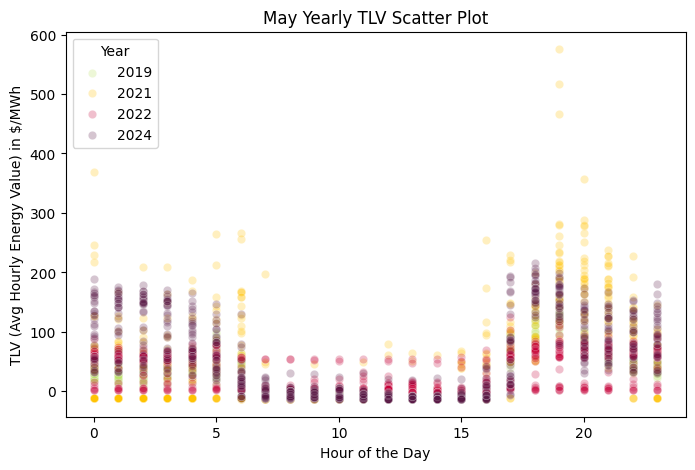

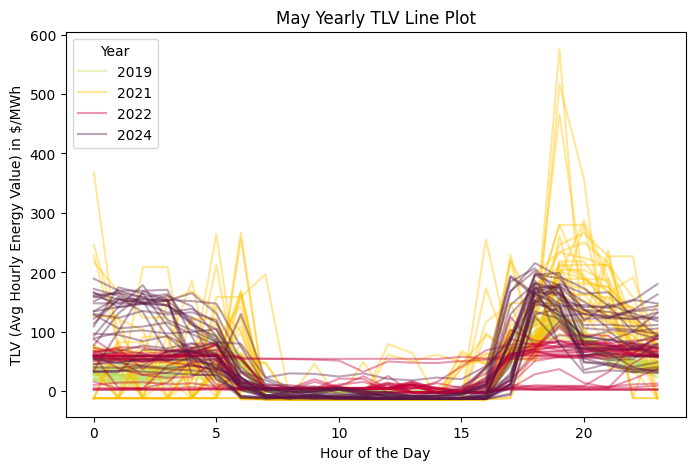

In [72]:
years = ["2019", "2021", "2022", "2024"]
# palette = ["red", "green", "blue", "purple"] 
palette = ["#bae161", "#FFC300", "#C70039", "#581845"] 
palette_dict = {"2019": "#bae161", "2021": "#FFC300", "2022": "#C70039", "2024": "#581845"}

yearly_data = [may19_data, may21_data, may22_data, may24_data]  # DataFrames for each year

# --- Scatter Plot ---
plt.figure(figsize=(8, 5))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.scatterplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.25)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("May Yearly TLV Scatter Plot")
plt.legend(title="Year", loc="upper left")
plt.show()

# --- Line Plot ---
plt.figure(figsize=(8, 5))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("May Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


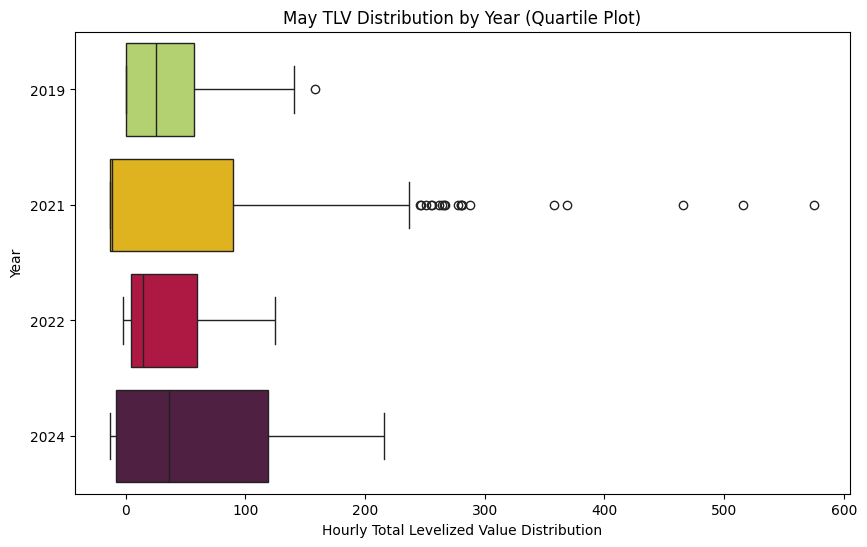

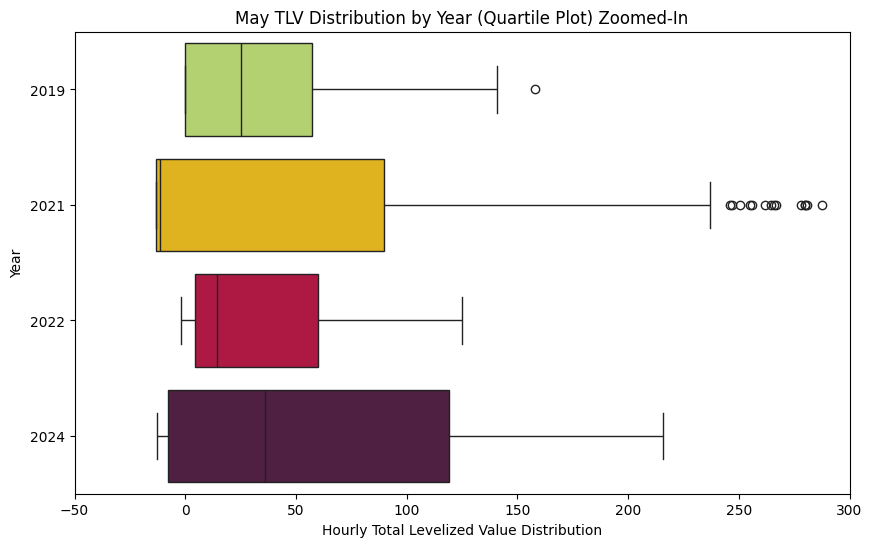

In [73]:
# Add a "Year" column to each DataFrame
may19_data_temporal_melted["Year"] = "2019"
may21_data_temporal_melted["Year"] = "2021"
may22_data_temporal_melted["Year"] = "2022"
may24_data_temporal_melted["Year"] = "2024"

# Combine both datasets into one
yearly_temporal_data = [may19_data_temporal_melted, may21_data_temporal_melted, may22_data_temporal_melted, may24_data_temporal_melted]
combined_data = pd.concat(yearly_temporal_data)

plt.figure(figsize=(10, 6))

# Create stacked horizontal box plots (assign hue for color separation)
sns.boxplot(x="Value", y="Year", data=combined_data, hue="Year", palette=palette_dict, legend=False)

# Set labels and title
plt.xlabel("Hourly Total Levelized Value Distribution")
plt.ylabel("Year")
plt.title("May TLV Distribution by Year (Quartile Plot)")


plt.show()

plt.figure(figsize=(10, 6))
# Create stacked horizontal box plots (assign hue for color separation)
sns.boxplot(x="Value", y="Year", data=combined_data, hue="Year", palette=palette_dict, legend=False)

# Set labels and title
plt.xlabel("Hourly Total Levelized Value Distribution")
plt.ylabel("Year")
plt.title("May TLV Distribution by Year (Quartile Plot) Zoomed-In")
plt.xlim(-50, 300)

plt.show()


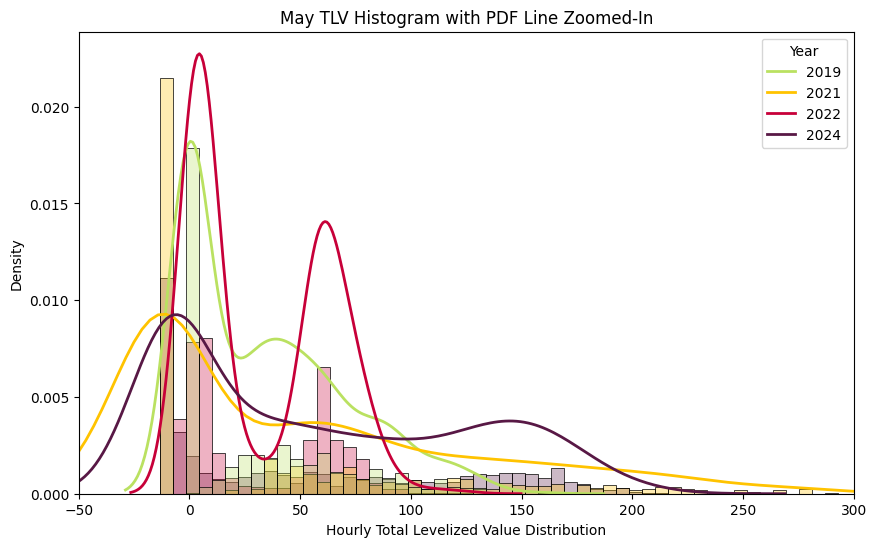

In [15]:
plt.figure(figsize=(10, 6))

# Create histogram with transparency
sns.histplot(data=combined_data, x="Value", hue="Year", bins=100, stat="density", 
             palette = palette_dict, 
             alpha=0.3)

# Overlay PDF line using KDE plot with explicit labels
for i, data in enumerate(yearly_temporal_data):  # Iterate over datasets
    year = years[i]
    color = palette[i]
    subset = combined_data[combined_data["Year"] == year]
    sns.kdeplot(x=subset["Value"], color=color, linewidth=2, label=year)

# Set labels and title
plt.xlabel("Hourly Total Levelized Value Distribution")
plt.ylabel("Density")
plt.title("May TLV Histogram with PDF Line Zoomed-In")
plt.xlim(-50, 300)
plt.legend(title="Year")
plt.show()


#### Year to Year Comparisons

2019 to 2021

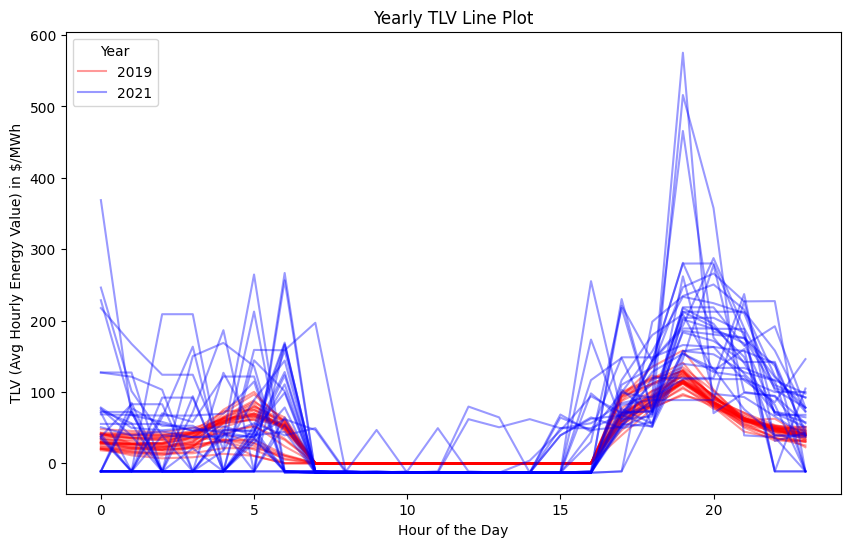

In [17]:
years = ["2019", "2021"]
palette = ["red", "blue"] 

yearly_data = [may19_data, may21_data]  # DataFrames for each year

plt.figure(figsize=(10, 6))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


2021 to 2022

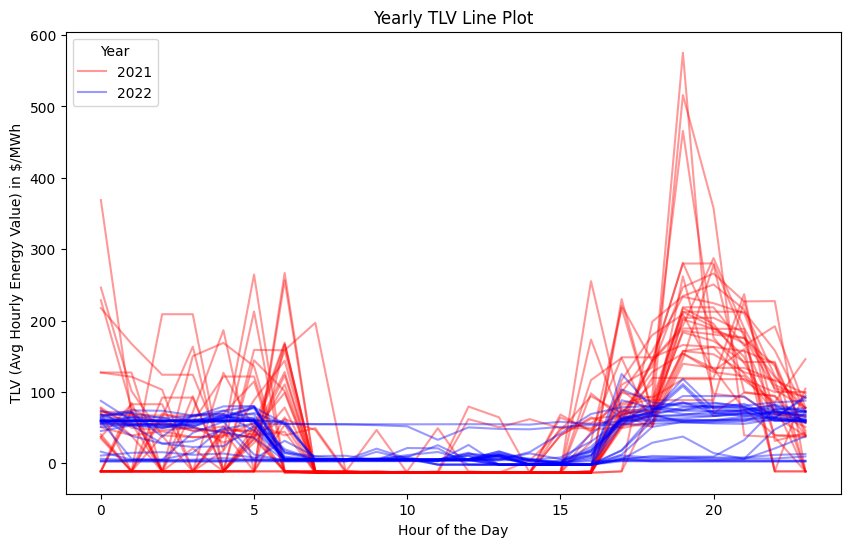

In [18]:
years = ["2021", "2022"]
palette = ["red", "blue"] 

yearly_data = [may21_data, may22_data]  # DataFrames for each year

plt.figure(figsize=(10, 6))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


2022 to 2024

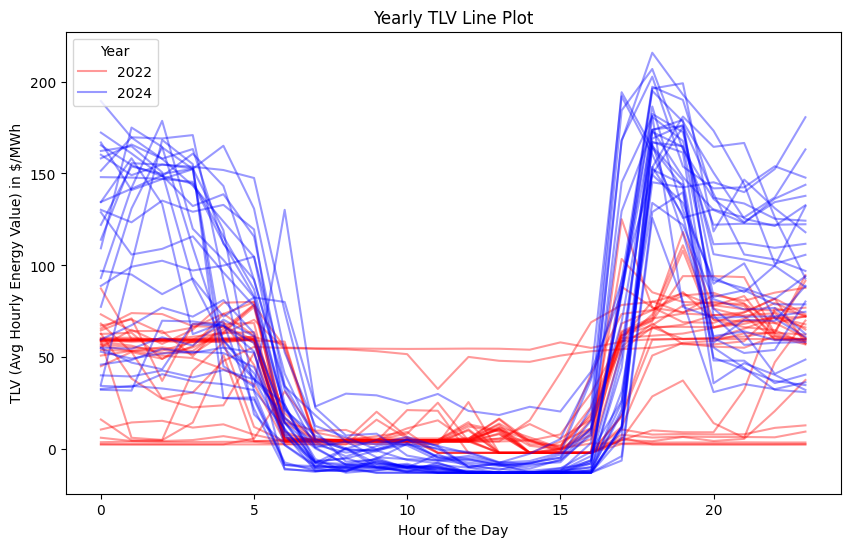

In [22]:
years = ["2022", "2024"]
palette = ["red", "blue"] 

yearly_data = [may22_data, may24_data]  # DataFrames for each year

plt.figure(figsize=(10, 6))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


In [23]:
# Initialize DataFrame for basic stats
yearly_distr = pd.DataFrame()

# List of datasets per year
years = ["2019", "2021", "2022", "2024"]

for i, data in enumerate(yearly_temporal_data):  # Iterate over datasets
    year = years[i]
    data_values = data["Value"].dropna()

    # Compute mean (μ) and standard deviation (σ)
    mu = np.mean(data_values)
    sigma = np.std(data_values, ddof=1)  # Sample std dev

    # Compute IQR for outlier detection
    Q1 = np.percentile(data_values, 25)
    Q3 = np.percentile(data_values, 75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = data_values[(data_values < lower_bound) | (data_values > upper_bound)]
    num_outliers = len(outliers)

    # Store values in DataFrame
    yearly_distr.loc[year, "mean"] = mu
    yearly_distr.loc[year, "standard deviation"] = sigma
    yearly_distr.loc[year, "outlier count"] = num_outliers

# Calculating Marginal Difference Percentage
yearly_distr["% change in mean"] = yearly_distr["mean"].pct_change() * 100

print("Descriptive Stats: ")
yearly_distr

Descriptive Stats: 


,mean,standard deviation,outlier count,% change in mean
2019,32.836524,36.184691,1.0,NaN
2021,49.669006,82.784744,19.0,51.261463
2022,32.065488,30.771235,0.0,-35.441655
2024,55.823729,66.520530,0.0,74.092869


#### Creating Line of Best Fit Drawing for ALl Years

2019

sigma:  2.3
weight vector:  [ 19.9370934   51.88871311   2.37890795  -0.8062563   -1.12277001
 113.29057145  24.43985869]


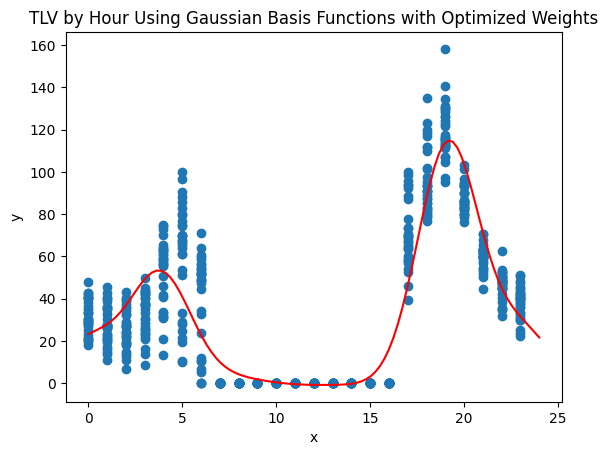

In [80]:
# Parameters
mu = np.linspace(0, 23, 7) # Uses 7 mu's equally spaced out
sigma = (max(x) - min(x)) / 10 #using (max(x) - min(x))/(# of basis functions) for sigma


w = gaussian_weights(x_19, y_19, mu, sigma) #Optimal weight vectors given x and y in dataset

print("sigma: ", sigma)
print("weight vector: ", w)

# Plotting H(x) prediction line on data
x_reg = np.linspace(0, 24, 100)
H_19= plot_h(x_reg, mu, w, sigma)

plt.plot(x_reg, H_19, color="red")
plt.scatter(x_19, y_19)

# Add labels and legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('TLV by Hour Using Gaussian Basis Functions with Optimized Weights')
plt.show()


2021

sigma:  2.3
weight vector:  [ 44.17005046  47.86818946   3.80647832 -13.89860197  -6.01620226
 200.22376959  52.88822753]


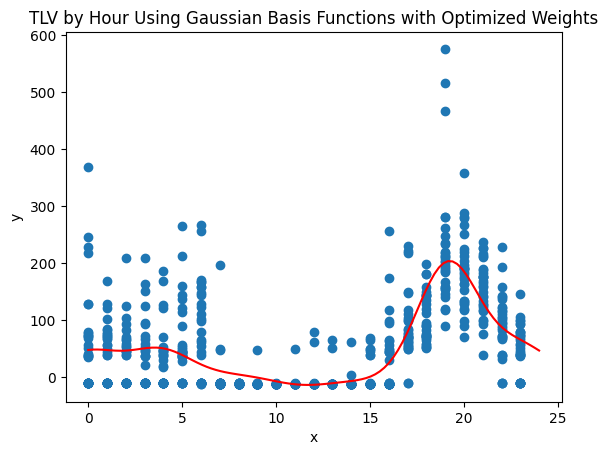

In [81]:
# Parameters
mu = np.linspace(0, 23, 7) # Uses 7 mu's equally spaced out
sigma = (max(x) - min(x)) / 10 #using (max(x) - min(x))/(# of basis functions) for sigma


w = gaussian_weights(x_21, y_21, mu, sigma) #Optimal weight vectors given x and y in dataset

print("sigma: ", sigma)
print("weight vector: ", w)

# Plotting H(x) prediction line on data
x_reg = np.linspace(0, 24, 100)
H_21 = plot_h(x_reg, mu, w, sigma)

plt.plot(x_reg, H_21, color="red")
plt.scatter(x_21, y_21)

# Add labels and legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('TLV by Hour Using Gaussian Basis Functions with Optimized Weights')
plt.show()


2022

sigma:  2.3
weight vector:  [44.76296609 48.78134623  4.06434744  8.33690061  7.33993143 59.95444957
 52.10502067]


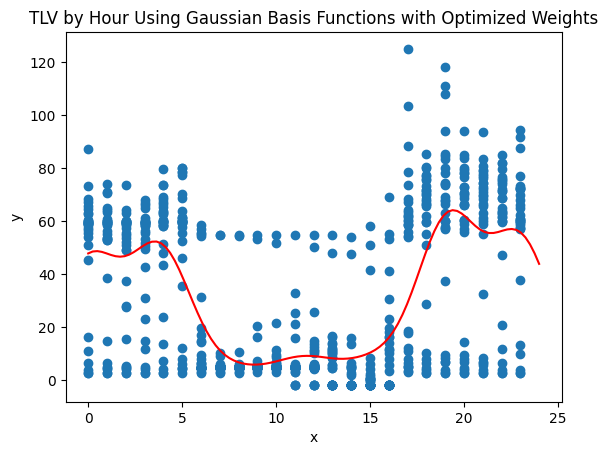

In [82]:
# Parameters
mu = np.linspace(0, 23, 7) # Uses 7 mu's equally spaced out
sigma = (max(x) - min(x)) / 10 #using (max(x) - min(x))/(# of basis functions) for sigma


w = gaussian_weights(x_22, y_22, mu, sigma) #Optimal weight vectors given x and y in dataset

print("sigma: ", sigma)
print("weight vector: ", w)

# Plotting H(x) prediction line on data
x_reg = np.linspace(0, 24, 100)
H_22 = plot_h(x_reg, mu, w, sigma)

plt.plot(x_reg, H_22, color="red")
plt.scatter(x_22, y_22)

# Add labels and legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('TLV by Hour Using Gaussian Basis Functions with Optimized Weights')
plt.show()


2024

sigma:  2.3
weight vector:  [111.6248724   92.305826   -12.02506884  -6.40061248  -7.69769879
 149.65594612  69.56920999]


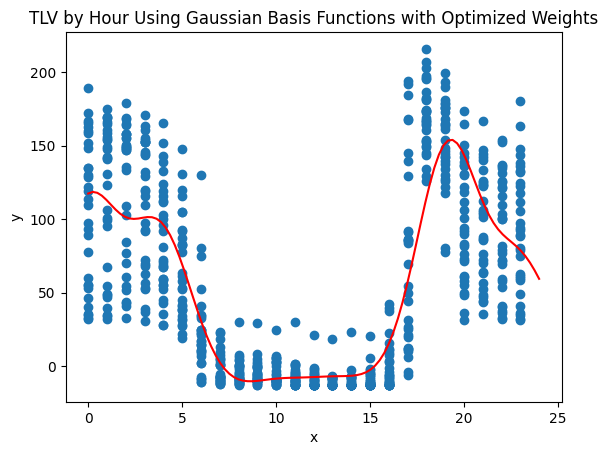

In [83]:
# Parameters
mu = np.linspace(0, 23, 7) # Uses 7 mu's equally spaced out
sigma = (max(x) - min(x)) / 10 #using (max(x) - min(x))/(# of basis functions) for sigma


w = gaussian_weights(x_24, y_24, mu, sigma) #Optimal weight vectors given x and y in dataset

print("sigma: ", sigma)
print("weight vector: ", w)

# Plotting H(x) prediction line on data
x_reg = np.linspace(0, 24, 100)
H_24= plot_h(x_reg, mu, w, sigma)

plt.plot(x_reg, H_24, color="red")
plt.scatter(x_24, y_24)

# Add labels and legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('TLV by Hour Using Gaussian Basis Functions with Optimized Weights')
plt.show()


Plotting all Gaussian line of best fits

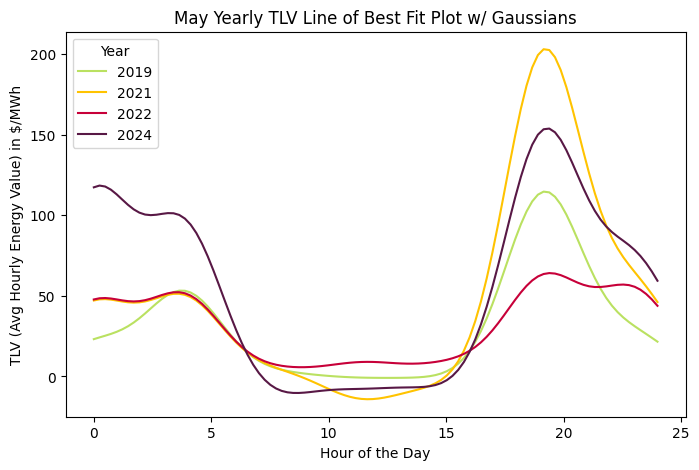

In [90]:
line_plots = [H_19, H_21, H_22, H_24]

# --- Line Plot ---
plt.figure(figsize=(8, 5))
for i, data in enumerate(line_plots):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    plt.plot(x_reg, line_plots[i], color=color, label=label)


plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("May Yearly TLV Line of Best Fit Plot w/ Gaussians")
plt.legend(title="Year", loc="upper left")
plt.show()


Regression Analysis

In [91]:
# Define response variable
response = 'Value'

# Define covariates
covariates = ["Day_of_Month", "Year", "hour_sin", "hour_cos"]


model_formula = f'{response} ~ {" + ".join(covariates)}'
print(f"Model Formula: {model_formula}")

# Splitting Data into training and testing sets
train_data, test_data = train_test_split(may_yearly_data, test_size=0.2, random_state=42)

# Training Model on Training Data
full_model = smf.ols(model_formula, data=train_data).fit()

# Making Predictions on Test Set
y_test = test_data[response]  # Actual values
y_pred = full_model.predict(test_data)  # Predicted values

# Computing RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(full_model.summary())
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Model Formula: Value ~ Day_of_Month + Year + hour_sin + hour_cos


NameError: name 'may_yearly_data' is not defined